Import pandas

In [3]:
import pandas as pd


Load our datasets

In [4]:
import pandas as pd

skills = pd.read_csv("../data/skills.csv")
jobs = pd.read_csv("../data/jobs.csv")

print("Skills loaded:", len(skills))
print("Jobs loaded:", len(jobs))

Skills loaded: 40
Jobs loaded: 8


In [5]:
sample_resume = """
Computer Science graduate with experience in Python, Pandas, NumPy,
machine learning, NLP, Hugging Face Transformers, PyTorch, SQL,
Git, GitHub and Docker. Experienced in Roman Urdu NLP, multilingual
transformers and natural language processing projects.
"""

In [6]:
print(len(jobs))
print(sample_resume[:50])

8

Computer Science graduate with experience in Pyth


Check the skills dataset

In [7]:
skills.head()

,skill,category
0,Python,Programming
1,Java,Programming
2,C++,Programming
3,SQL,Database
4,PostgreSQL,Database


Check the jobs

In [8]:
jobs.head()

,job_id,title,description
0,1,Data Scientist,We are looking for a Data Scientist with stron...
1,2,Machine Learning Engineer,Looking for a Machine Learning Engineer experi...
2,3,NLP Engineer,The candidate should have experience with Pyth...
3,4,AI Engineer,We are seeking an AI Engineer with experience ...
4,5,Data Analyst,"The ideal candidate has strong SQL, Python, Pa..."


Check dataset sizes

In [9]:
print("Number of skills:", len(skills))
print("Number of jobs:", len(jobs))

Number of skills: 40
Number of jobs: 8


how many skills appear in each job

In [10]:
for _, row in jobs.iterrows():
    print(f"\n{row['title']}")
    print("-" * 40)
    print(row["description"])


Data Scientist
----------------------------------------
We are looking for a Data Scientist with strong Python, Pandas, NumPy, SQL, statistics, machine learning and scikit-learn skills. Experience with data visualization and Power BI is preferred.

Machine Learning Engineer
----------------------------------------
Looking for a Machine Learning Engineer experienced in Python, PyTorch, TensorFlow, deep learning, machine learning, Docker and Git. Knowledge of NLP and transformers is a plus.

NLP Engineer
----------------------------------------
The candidate should have experience with Python, NLP, natural language processing, transformers, Hugging Face, PyTorch and large language models. Experience with RAG is preferred.

AI Engineer
----------------------------------------
We are seeking an AI Engineer with experience in Python, machine learning, deep learning, artificial intelligence, PyTorch, transformers, LLMs and Docker.

Data Analyst
----------------------------------------
The i

Create our first simple skill extractor

In [11]:
def extract_skills(text, skills_df):
    text = text.lower()
    found_skills = []

    for skill in skills_df["skill"]:
        if skill.lower() in text:
            found_skills.append(skill)

    return found_skills

In [12]:
test_job = jobs.iloc[0]["description"]

extract_skills(test_job, skills)

['Python',
 'SQL',
 'Pandas',
 'NumPy',
 'Scikit-learn',
 'Machine Learning',
 'Power BI',
 'Statistics']

Extract skills from every job

In [13]:
jobs["extracted_skills"] = jobs["description"].apply(
    lambda x: extract_skills(x, skills)
)

jobs[["title", "extracted_skills"]]

,title,extracted_skills
0,Data Scientist,"[Python, SQL, Pandas, NumPy, Scikit-learn, Mac..."
1,Machine Learning Engineer,"[Python, TensorFlow, PyTorch, NLP, Machine Lea..."
2,NLP Engineer,"[Python, PyTorch, Hugging Face, NLP, Natural L..."
3,AI Engineer,"[Python, PyTorch, Machine Learning, Deep Learn..."
4,Data Analyst,"[Python, SQL, Pandas, Power BI, Tableau, Stati..."
5,Backend Developer,"[Python, SQL, PostgreSQL, MySQL, FastAPI, Flas..."
6,Computer Vision Engineer,"[Python, NumPy, TensorFlow, PyTorch, Machine L..."
7,Generative AI Engineer,"[Python, PyTorch, Hugging Face, Transformers, ..."


Now create a simple CV for testing

In [14]:
sample_resume = """
Computer Science graduate with experience in Python, Pandas, NumPy,
machine learning, NLP, Hugging Face Transformers, PyTorch, SQL,
Git, GitHub and Docker. Experienced in Roman Urdu NLP, multilingual
transformers and natural language processing projects.
"""

In [15]:
resume_skills = extract_skills(sample_resume, skills)

resume_skills

['Python',
 'SQL',
 'Pandas',
 'NumPy',
 'PyTorch',
 'Hugging Face',
 'NLP',
 'Natural Language Processing',
 'Machine Learning',
 'Transformers',
 'Docker',
 'Git',
 'GitHub']

Calculate Skill Match

In [16]:
def calculate_skill_match(resume_skills, job_skills):
    resume_set = set(skill.lower() for skill in resume_skills)
    job_set = set(skill.lower() for skill in job_skills)

    matched = resume_set.intersection(job_set)
    missing = job_set - resume_set

    if len(job_set) == 0:
        score = 0
    else:
        score = (len(matched) / len(job_set)) * 100

    return score, list(matched), list(missing)

Test it with one job

In [17]:
job_skills = jobs.iloc[0]["extracted_skills"]

score, matched, missing = calculate_skill_match(
    resume_skills,
    job_skills
)

print("Match Score:", round(score, 2), "%")
print("\nMatched Skills:")
print(matched)

print("\nMissing Skills:")
print(missing)

Match Score: 62.5 %

Matched Skills:
['numpy', 'machine learning', 'python', 'pandas', 'sql']

Missing Skills:
['statistics', 'power bi', 'scikit-learn']


In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [19]:
vectorizer = TfidfVectorizer(stop_words="english")

documents = [sample_resume, jobs.iloc[0]["description"]]

tfidf_matrix = vectorizer.fit_transform(documents)

similarity = cosine_similarity(
    tfidf_matrix[0:1],
    tfidf_matrix[1:2]
)[0][0]

print("TF-IDF Similarity:", round(similarity * 100, 2), "%")

TF-IDF Similarity: 15.4 %


Test TF-IDF against ALL jobs

In [20]:
results = []

for _, row in jobs.iterrows():
    documents = [sample_resume, row["description"]]

    tfidf_matrix = vectorizer.fit_transform(documents)

    similarity = cosine_similarity(
        tfidf_matrix[0:1],
        tfidf_matrix[1:2]
    )[0][0]

    results.append({
        "job_id": row["job_id"],
        "title": row["title"],
        "tfidf_score": round(similarity * 100, 2)
    })

tfidf_results = pd.DataFrame(results)

tfidf_results.sort_values(
    "tfidf_score",
    ascending=False
)

,job_id,title,tfidf_score
2,3,NLP Engineer,39.89
1,2,Machine Learning Engineer,35.59
3,4,AI Engineer,25.22
6,7,Computer Vision Engineer,24.04
7,8,Generative AI Engineer,23.98
0,1,Data Scientist,15.40
5,6,Backend Developer,10.24
4,5,Data Analyst,9.87


Let's combine the two approaches

In [68]:
skills = [
    "Python",
    "Java",
    "C++",
    "SQL",
    "PostgreSQL",
    "MySQL",
    "Pandas",
    "NumPy",
    "Scikit-learn",
    "TensorFlow",
    "PyTorch",
    "Machine Learning",
    "Deep Learning",
    "NLP",
    "Natural Language Processing",
    "Transformers",
    "Hugging Face",
    "Large Language Models",
    "LLM",
    "RAG",
    "FAISS",
    "Docker",
    "Git",
    "GitHub",
    "Statistics",
    "Power BI",
    "Tableau",
    "FastAPI",
    "Flask",
    "Artificial Intelligence",
    "Computer Vision",
    "Data Science",
    "Generative AI",
    "SQL Server",
    "Keras",
    "Scipy"
]

skills_df = pd.DataFrame({
    "skill": skills
})

In [21]:
results = []

for _, row in jobs.iterrows():
    job_skills = row["extracted_skills"]

    skill_score, matched, missing = calculate_skill_match(
        resume_skills,
        job_skills
    )

    documents = [sample_resume, row["description"]]

    tfidf_matrix = vectorizer.fit_transform(documents)

    similarity = cosine_similarity(
        tfidf_matrix[0:1],
        tfidf_matrix[1:2]
    )[0][0] * 100

    results.append({
        "job_id": row["job_id"],
        "title": row["title"],
        "skill_score": round(skill_score, 2),
        "tfidf_score": round(similarity, 2),
        "matched_skills": matched,
        "missing_skills": missing
    })

results_df = pd.DataFrame(results)

results_df

,job_id,title,skill_score,tfidf_score,matched_skills,missing_skills
0,1,Data Scientist,62.50,15.40,"[numpy, machine learning, python, pandas, sql]","[statistics, power bi, scikit-learn]"
1,2,Machine Learning Engineer,77.78,35.59,"[transformers, nlp, git, machine learning, pyt...","[deep learning, tensorflow]"
2,3,NLP Engineer,75.00,39.89,"[transformers, nlp, hugging face, python, pyto...","[large language models, rag]"
3,4,AI Engineer,62.50,25.22,"[transformers, machine learning, python, docke...","[deep learning, artificial intelligence, llm]"
4,5,Data Analyst,50.00,9.87,"[sql, python, pandas]","[statistics, tableau, power bi]"
5,6,Backend Developer,50.00,10.24,"[git, docker, python, sql]","[mysql, fastapi, postgresql, flask]"
6,7,Computer Vision Engineer,57.14,24.04,"[machine learning, python, numpy, pytorch]","[computer vision, deep learning, tensorflow]"
7,8,Generative AI Engineer,50.00,23.98,"[hugging face, python, transformers, pytorch]","[large language models, faiss, rag, llm]"


Create the Hybrid Score

In [22]:
results_df["hybrid_score"] = (
    0.5 * results_df["skill_score"] +
    0.5 * results_df["tfidf_score"]
)

results_df[
    ["title", "skill_score", "tfidf_score", "hybrid_score"]
].sort_values(
    "hybrid_score",
    ascending=False
)

,title,skill_score,tfidf_score,hybrid_score
2,NLP Engineer,75.00,39.89,57.445
1,Machine Learning Engineer,77.78,35.59,56.685
3,AI Engineer,62.50,25.22,43.860
6,Computer Vision Engineer,57.14,24.04,40.590
0,Data Scientist,62.50,15.40,38.950
7,Generative AI Engineer,50.00,23.98,36.990
5,Backend Developer,50.00,10.24,30.120
4,Data Analyst,50.00,9.87,29.935


In [23]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

print("Model loaded successfully!")

Loading weights:   0%|          | 0/103 [00:01<?, ?it/s]

Model loaded successfully!


In [24]:
import pandas as pd

skills = pd.read_csv("../data/skills.csv")
jobs = pd.read_csv("../data/jobs.csv")

sample_resume = """
Computer Science graduate with experience in Python, Pandas, NumPy,
machine learning, NLP, Hugging Face Transformers, PyTorch, SQL,
Git, GitHub and Docker. Experienced in Roman Urdu NLP, multilingual
transformers and natural language processing projects.
"""

print("Data loaded successfully!")

Data loaded successfully!


Compare your resume with the Data Scientist job

In [25]:
resume_embedding = model.encode(sample_resume)
job_embedding = model.encode(jobs.iloc[0]["description"])

print("Resume embedding shape:", resume_embedding.shape)
print("Job embedding shape:", job_embedding.shape)

Resume embedding shape: (384,)
Job embedding shape: (384,)


Calculate semantic similarity

In [26]:
from sklearn.metrics.pairwise import cosine_similarity

semantic_similarity = cosine_similarity(
    [resume_embedding],
    [job_embedding]
)[0][0]

print("Semantic Similarity:", round(semantic_similarity * 100, 2), "%")

Semantic Similarity: 53.21 %


In [27]:
semantic_results = []

for _, row in jobs.iterrows():
    job_embedding = model.encode(row["description"])

    similarity = cosine_similarity(
        [resume_embedding],
        [job_embedding]
    )[0][0] * 100

    semantic_results.append({
        "job_id": row["job_id"],
        "title": row["title"],
        "semantic_score": round(similarity, 2)
    })

semantic_results_df = pd.DataFrame(semantic_results)

semantic_results_df.sort_values(
    "semantic_score",
    ascending=False
)

,job_id,title,semantic_score
2,3,NLP Engineer,70.389999
1,2,Machine Learning Engineer,64.589996
7,8,Generative AI Engineer,64.190002
6,7,Computer Vision Engineer,53.750000
3,4,AI Engineer,53.340000
0,1,Data Scientist,53.209999
4,5,Data Analyst,53.040001
5,6,Backend Developer,44.470001


In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

vectorizer = TfidfVectorizer(stop_words="english")

print("TF-IDF vectorizer ready!")

TF-IDF vectorizer ready!


In [29]:
# Recreate skill extraction
def extract_skills(text, skills_df):
    text = text.lower()
    found_skills = []

    for skill in skills_df["skill"]:
        if skill.lower() in text:
            found_skills.append(skill)

    return found_skills


# Recreate skill matching
def calculate_skill_match(resume_skills, job_skills):
    resume_set = set(skill.lower() for skill in resume_skills)
    job_set = set(skill.lower() for skill in job_skills)

    matched = resume_set.intersection(job_set)
    missing = job_set - resume_set

    if len(job_set) == 0:
        score = 0
    else:
        score = (len(matched) / len(job_set)) * 100

    return score, list(matched), list(missing)


# Extract skills from resume
resume_skills = extract_skills(sample_resume, skills)

results = []

for _, row in jobs.iterrows():

    # Skill score
    job_skills = extract_skills(row["description"], skills)

    skill_score, matched, missing = calculate_skill_match(
        resume_skills,
        job_skills
    )

    # TF-IDF score
    documents = [sample_resume, row["description"]]

    tfidf_matrix = vectorizer.fit_transform(documents)

    tfidf_score = cosine_similarity(
        tfidf_matrix[0:1],
        tfidf_matrix[1:2]
    )[0][0] * 100

    # Semantic score
    job_embedding = model.encode(row["description"])

    semantic_score = cosine_similarity(
        [resume_embedding],
        [job_embedding]
    )[0][0] * 100

    results.append({
        "job_id": row["job_id"],
        "title": row["title"],
        "skill_score": round(skill_score, 2),
        "tfidf_score": round(tfidf_score, 2),
        "semantic_score": round(semantic_score, 2),
        "matched_skills": matched,
        "missing_skills": missing
    })


results_df = pd.DataFrame(results)

results_df[
    ["title", "skill_score", "tfidf_score", "semantic_score"]
]

,title,skill_score,tfidf_score,semantic_score
0,Data Scientist,62.50,15.40,53.209999
1,Machine Learning Engineer,77.78,35.59,64.589996
2,NLP Engineer,75.00,39.89,70.389999
3,AI Engineer,62.50,25.22,53.340000
4,Data Analyst,50.00,9.87,53.040001
5,Backend Developer,50.00,10.24,44.470001
6,Computer Vision Engineer,57.14,24.04,53.750000
7,Generative AI Engineer,50.00,23.98,64.190002


Calculate the hybrid score

In [30]:
results_df["hybrid_score"] = (
    0.40 * results_df["skill_score"] +
    0.20 * results_df["tfidf_score"] +
    0.40 * results_df["semantic_score"]
)

final_results = results_df[
    ["title", "skill_score", "tfidf_score", "semantic_score", "hybrid_score"]
].sort_values(
    "hybrid_score",
    ascending=False
)

final_results

,title,skill_score,tfidf_score,semantic_score,hybrid_score
2,NLP Engineer,75.00,39.89,70.389999,66.134000
1,Machine Learning Engineer,77.78,35.59,64.589996,64.065999
3,AI Engineer,62.50,25.22,53.340000,51.380000
7,Generative AI Engineer,50.00,23.98,64.190002,50.472001
0,Data Scientist,62.50,15.40,53.209999,49.364000
6,Computer Vision Engineer,57.14,24.04,53.750000,49.164000
4,Data Analyst,50.00,9.87,53.040001,43.190002
5,Backend Developer,50.00,10.24,44.470001,39.836000


In [31]:
final_results.to_csv(
    "../data/model_results.csv",
    index=False
)

print("Results saved successfully!")

Results saved successfully!


In [32]:
# Skill Gap Analysis

skill_gap = results_df[
    ["title", "matched_skills", "missing_skills"]
].copy()

skill_gap

,title,matched_skills,missing_skills
0,Data Scientist,"[numpy, machine learning, python, pandas, sql]","[statistics, power bi, scikit-learn]"
1,Machine Learning Engineer,"[transformers, nlp, git, machine learning, pyt...","[deep learning, tensorflow]"
2,NLP Engineer,"[transformers, nlp, hugging face, python, pyto...","[large language models, rag]"
3,AI Engineer,"[transformers, machine learning, python, docke...","[deep learning, artificial intelligence, llm]"
4,Data Analyst,"[sql, python, pandas]","[statistics, tableau, power bi]"
5,Backend Developer,"[git, docker, python, sql]","[mysql, fastapi, postgresql, flask]"
6,Computer Vision Engineer,"[machine learning, python, numpy, pytorch]","[computer vision, deep learning, tensorflow]"
7,Generative AI Engineer,"[hugging face, python, transformers, pytorch]","[large language models, faiss, rag, llm]"


In [33]:
# Create a clean skill-gap report

for _, row in results_df.iterrows():
    print("=" * 60)
    print("JOB:", row["title"])
    print("Matched Skills:", ", ".join(row["matched_skills"]))
    print("Missing Skills:", ", ".join(row["missing_skills"]))

JOB: Data Scientist
Matched Skills: numpy, machine learning, python, pandas, sql
Missing Skills: statistics, power bi, scikit-learn
JOB: Machine Learning Engineer
Matched Skills: transformers, nlp, git, machine learning, python, docker, pytorch
Missing Skills: deep learning, tensorflow
JOB: NLP Engineer
Matched Skills: transformers, nlp, hugging face, python, pytorch, natural language processing
Missing Skills: large language models, rag
JOB: AI Engineer
Matched Skills: transformers, machine learning, python, docker, pytorch
Missing Skills: deep learning, artificial intelligence, llm
JOB: Data Analyst
Matched Skills: sql, python, pandas
Missing Skills: statistics, tableau, power bi
JOB: Backend Developer
Matched Skills: git, docker, python, sql
Missing Skills: mysql, fastapi, postgresql, flask
JOB: Computer Vision Engineer
Matched Skills: machine learning, python, numpy, pytorch
Missing Skills: computer vision, deep learning, tensorflow
JOB: Generative AI Engineer
Matched Skills: huggi

In [34]:
results_df.columns

Index(['job_id', 'title', 'skill_score', 'tfidf_score', 'semantic_score',
       'matched_skills', 'missing_skills', 'hybrid_score'],
      dtype='str')

In [35]:
# Show the final hybrid ranking

results_df[
    ["title", "skill_score", "tfidf_score", "semantic_score", "hybrid_score"]
].sort_values(
    by="hybrid_score",
    ascending=False
).reset_index(drop=True)

,title,skill_score,tfidf_score,semantic_score,hybrid_score
0,NLP Engineer,75.00,39.89,70.389999,66.134000
1,Machine Learning Engineer,77.78,35.59,64.589996,64.065999
2,AI Engineer,62.50,25.22,53.340000,51.380000
3,Generative AI Engineer,50.00,23.98,64.190002,50.472001
4,Data Scientist,62.50,15.40,53.209999,49.364000
5,Computer Vision Engineer,57.14,24.04,53.750000,49.164000
6,Data Analyst,50.00,9.87,53.040001,43.190002
7,Backend Developer,50.00,10.24,44.470001,39.836000


In [36]:
from collections import Counter

# Collect all missing skills
all_missing_skills = []

for skills in results_df["missing_skills"]:
    all_missing_skills.extend(skills)

# Count how often each missing skill appears
skill_gap_counts = Counter(all_missing_skills)

# Convert to a clean dataframe
skill_gap_df = pd.DataFrame(
    skill_gap_counts.items(),
    columns=["skill", "job_count"]
)

# Sort by frequency
skill_gap_df = skill_gap_df.sort_values(
    by="job_count",
    ascending=False
).reset_index(drop=True)

skill_gap_df

,skill,job_count
0,deep learning,3
1,statistics,2
2,power bi,2
3,tensorflow,2
4,rag,2
5,large language models,2
6,llm,2
7,scikit-learn,1
8,artificial intelligence,1
9,tableau,1


Create a Skill Gap Priority Score

In [37]:
# Create skill-gap priority levels

def get_priority(count):
    if count >= 3:
        return "High"
    elif count == 2:
        return "Medium"
    else:
        return "Low"


skill_gap_df["priority"] = skill_gap_df["job_count"].apply(get_priority)

skill_gap_df

,skill,job_count,priority
0,deep learning,3,High
1,statistics,2,Medium
2,power bi,2,Medium
3,tensorflow,2,Medium
4,rag,2,Medium
5,large language models,2,Medium
6,llm,2,Medium
7,scikit-learn,1,Low
8,artificial intelligence,1,Low
9,tableau,1,Low


Skill-gap visualization

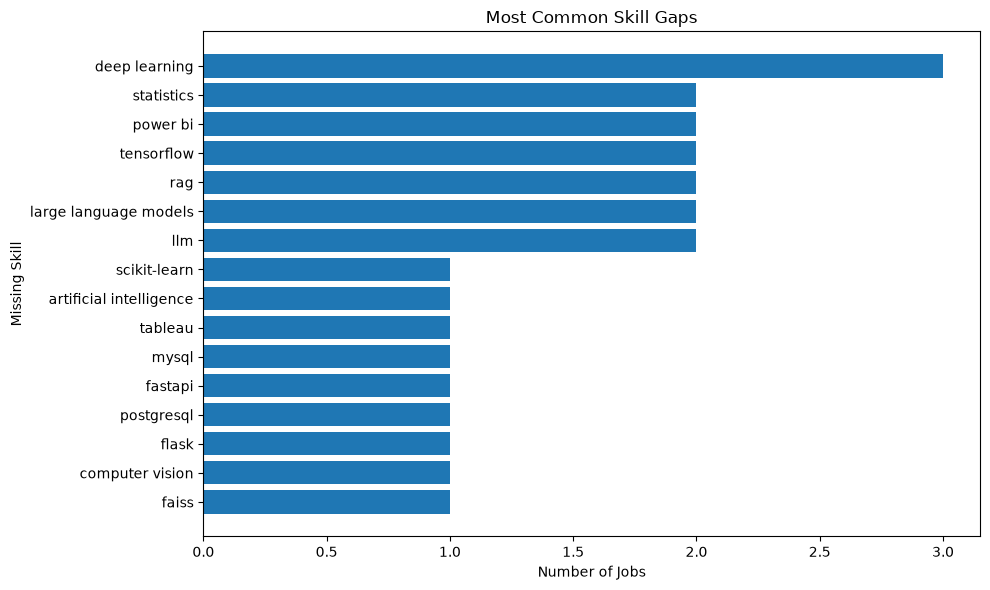

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    skill_gap_df["skill"],
    skill_gap_df["job_count"]
)

plt.xlabel("Number of Jobs")
plt.ylabel("Missing Skill")
plt.title("Most Common Skill Gaps")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

Create learning recommendations

In [39]:
# Map missing skills to recommended learning areas

learning_map = {
    "deep learning": "Deep Learning with PyTorch",
    "statistics": "Statistics for Data Science",
    "tensorflow": "TensorFlow and Deep Learning",
    "power bi": "Power BI for Data Analysis",
    "large language models": "Large Language Models (LLMs)",
    "rag": "Retrieval-Augmented Generation (RAG)",
    "llm": "Large Language Models (LLMs)",
    "scikit-learn": "Scikit-learn for Machine Learning",
    "artificial intelligence": "Artificial Intelligence Fundamentals",
    "tableau": "Tableau for Data Visualization",
    "fastapi": "FastAPI for Python APIs",
    "postgresql": "PostgreSQL",
    "mysql": "MySQL",
    "flask": "Flask Web Development",
    "computer vision": "Computer Vision",
    "faiss": "FAISS and Vector Databases"
}

skill_gap_df["recommended_learning"] = skill_gap_df["skill"].map(learning_map)

skill_gap_df

,skill,job_count,priority,recommended_learning
0,deep learning,3,High,Deep Learning with PyTorch
1,statistics,2,Medium,Statistics for Data Science
2,power bi,2,Medium,Power BI for Data Analysis
3,tensorflow,2,Medium,TensorFlow and Deep Learning
4,rag,2,Medium,Retrieval-Augmented Generation (RAG)
5,large language models,2,Medium,Large Language Models (LLMs)
6,llm,2,Medium,Large Language Models (LLMs)
7,scikit-learn,1,Low,Scikit-learn for Machine Learning
8,artificial intelligence,1,Low,Artificial Intelligence Fundamentals
9,tableau,1,Low,Tableau for Data Visualization


Group duplicate learning areas

In [40]:
# Group related skills into the same learning area

learning_groups = {
    "Large Language Models (LLMs)": [
        "llm",
        "large language models"
    ],
    "Deep Learning with PyTorch": [
        "deep learning"
    ],
    "TensorFlow and Deep Learning": [
        "tensorflow"
    ],
    "Retrieval-Augmented Generation (RAG)": [
        "rag"
    ],
    "Statistics for Data Science": [
        "statistics"
    ],
    "Power BI for Data Analysis": [
        "power bi"
    ],
    "Scikit-learn for Machine Learning": [
        "scikit-learn"
    ],
    "Artificial Intelligence Fundamentals": [
        "artificial intelligence"
    ],
    "Tableau for Data Visualization": [
        "tableau"
    ],
    "FastAPI for Python APIs": [
        "fastapi"
    ],
    "PostgreSQL": [
        "postgresql"
    ],
    "MySQL": [
        "mysql"
    ],
    "Flask Web Development": [
        "flask"
    ],
    "Computer Vision": [
        "computer vision"
    ],
    "FAISS and Vector Databases": [
        "faiss"
    ]
}

grouped_gaps = []

for learning_area, skills in learning_groups.items():
    matching_rows = skill_gap_df[
        skill_gap_df["skill"].isin(skills)
    ]

    if not matching_rows.empty:
        grouped_gaps.append({
            "learning_area": learning_area,
            "job_count": matching_rows["job_count"].max(),
            "priority": matching_rows["priority"].iloc[0],
            "related_skills": ", ".join(matching_rows["skill"])
        })

grouped_gaps_df = pd.DataFrame(grouped_gaps)

grouped_gaps_df = grouped_gaps_df.sort_values(
    by="job_count",
    ascending=False
).reset_index(drop=True)

grouped_gaps_df

,learning_area,job_count,priority,related_skills
0,Deep Learning with PyTorch,3,High,deep learning
1,Large Language Models (LLMs),2,Medium,"large language models, llm"
2,TensorFlow and Deep Learning,2,Medium,tensorflow
3,Retrieval-Augmented Generation (RAG),2,Medium,rag
4,Statistics for Data Science,2,Medium,statistics
5,Power BI for Data Analysis,2,Medium,power bi
6,Scikit-learn for Machine Learning,1,Low,scikit-learn
7,Artificial Intelligence Fundamentals,1,Low,artificial intelligence
8,Tableau for Data Visualization,1,Low,tableau
9,FastAPI for Python APIs,1,Low,fastapi


In [41]:
# Generate final job recommendations

print("=" * 70)
print("AI JOB SKILL GAP ANALYZER - FINAL REPORT")
print("=" * 70)

print("\nTOP JOB MATCHES")
print("-" * 70)

for i, row in results_df.sort_values(
    by="hybrid_score",
    ascending=False
).head(5).iterrows():

    print(f"\nJob: {row['title']}")
    print(f"Hybrid Match: {row['hybrid_score']:.2f}%")
    print(f"Skill Match: {row['skill_score']:.2f}%")
    print(f"Semantic Similarity: {row['semantic_score']:.2f}%")
    print(f"Matched Skills: {', '.join(row['matched_skills'])}")
    print(f"Missing Skills: {', '.join(row['missing_skills'])}")

print("\n" + "=" * 70)
print("TOP SKILL GAPS")
print("=" * 70)

for _, row in grouped_gaps_df.head(7).iterrows():

    print(f"\nLearning Area: {row['learning_area']}")
    print(f"Priority: {row['priority']}")
    print(f"Required by: {row['job_count']} job(s)")
    print(f"Related Skills: {row['related_skills']}")

print("\n" + "=" * 70)

AI JOB SKILL GAP ANALYZER - FINAL REPORT

TOP JOB MATCHES
----------------------------------------------------------------------

Job: NLP Engineer
Hybrid Match: 66.13%
Skill Match: 75.00%
Semantic Similarity: 70.39%
Matched Skills: transformers, nlp, hugging face, python, pytorch, natural language processing
Missing Skills: large language models, rag

Job: Machine Learning Engineer
Hybrid Match: 64.07%
Skill Match: 77.78%
Semantic Similarity: 64.59%
Matched Skills: transformers, nlp, git, machine learning, python, docker, pytorch
Missing Skills: deep learning, tensorflow

Job: AI Engineer
Hybrid Match: 51.38%
Skill Match: 62.50%
Semantic Similarity: 53.34%
Matched Skills: transformers, machine learning, python, docker, pytorch
Missing Skills: deep learning, artificial intelligence, llm

Job: Generative AI Engineer
Hybrid Match: 50.47%
Skill Match: 50.00%
Semantic Similarity: 64.19%
Matched Skills: hugging face, python, transformers, pytorch
Missing Skills: large language models, faiss

Save the results as CSV files

In [42]:
# Save analysis results

results_df.to_csv(
    "job_match_results.csv",
    index=False
)

skill_gap_df.to_csv(
    "skill_gap_analysis.csv",
    index=False
)

grouped_gaps_df.to_csv(
    "learning_recommendations.csv",
    index=False
)

print("All analysis files saved successfully.")

All analysis files saved successfully.


In [43]:
# Show variables currently available in the notebook

%whos

Variable                Type                   Data/Info
--------------------------------------------------------
Counter                 type                   <class 'collections.Counter'>
Path                    type                   <class 'pathlib._local.Path'>
SentenceTransformer     ABCMeta                <class 'sentence_transfor<...>del.SentenceTransformer'>
TfidfVectorizer         type                   <class 'sklearn.feature_e<...>on.text.TfidfVectorizer'>
all_missing_skills      list                   n=24
analyze_job             function               <function analyze_job at 0x0000020EA711B420>
calculate_skill_match   function               <function calculate_skill<...>ch at 0x0000020EC7C3CF40>
cosine_similarity       function               <function cosine_similari<...>ty at 0x0000020EB7E025C0>
documents               list                   n=2
extract_skills          function               <function extract_skills at 0x0000020EC7C3E3E0>
final_results           DataFr

In [44]:
print("========== extract_skills ==========")
print(extract_skills)

print("\n========== calculate_skill_match ==========")
print(calculate_skill_match)

========== extract_skills ==========
<function extract_skills at 0x0000020EC7C3E3E0>

========== calculate_skill_match ==========
<function calculate_skill_match at 0x0000020EC7C3CF40>


In [45]:
import inspect

print("========== extract_skills ==========")
print(inspect.getsource(extract_skills))

print("\n========== calculate_skill_match ==========")
print(inspect.getsource(calculate_skill_match))

========== extract_skills ==========
def extract_skills(text, skills_df):
    text = text.lower()
    found_skills = []

    for skill in skills_df["skill"]:
        if skill.lower() in text:
            found_skills.append(skill)

    return found_skills


========== calculate_skill_match ==========
def calculate_skill_match(resume_skills, job_skills):
    resume_set = set(skill.lower() for skill in resume_skills)
    job_set = set(skill.lower() for skill in job_skills)

    matched = resume_set.intersection(job_set)
    missing = job_set - resume_set

    if len(job_set) == 0:
        score = 0
    else:
        score = (len(matched) / len(job_set)) * 100

    return score, list(matched), list(missing)



In [46]:
def extract_skills(text, skills_df):
    text = text.lower()
    found_skills = []

    for skill in skills_df["skill"]:
        if skill.lower() in text:
            found_skills.append(skill)

    return found_skills


def calculate_skill_match(resume_skills, job_skills):
    resume_set = set(skill.lower() for skill in resume_skills)
    job_set = set(skill.lower() for skill in job_skills)

    matched = resume_set.intersection(job_set)
    missing = job_set - resume_set

    if len(job_set) == 0:
        score = 0
    else:
        score = (len(matched) / len(job_set)) * 100

    return score, list(matched), list(missing)

In [47]:
import os

print(os.getcwd())
print(os.listdir())

c:\Users\shahid\Desktop\ai-job-skill-gap-analyzer\notebooks
['01_data_exploration.ipynb', 'job_match_results.csv', 'learning_recommendations.csv', 'skill_gap_analysis.csv', '__pycache__']


In [48]:
def extract_skills(text, skills_df):
    text = text.lower()
    found_skills = []

    for skill in skills_df["skill"]:
        if skill.lower() in text:
            found_skills.append(skill)

    return found_skills


def calculate_skill_match(resume_skills, job_skills):
    resume_set = set(skill.lower() for skill in resume_skills)
    job_set = set(skill.lower() for skill in job_skills)

    matched = resume_set.intersection(job_set)
    missing = job_set - resume_set

    if len(job_set) == 0:
        score = 0
    else:
        score = (len(matched) / len(job_set)) * 100

    return score, list(matched), list(missing)

In [49]:
import os

print(os.path.exists("skill_extractor.py"))

False


In [52]:
from src.skill_extractor import extract_skills
from src.job_matcher import match_job

print("Skill extractor and job matcher modules loaded successfully!")

Skill extractor and job matcher modules loaded successfully!


Import job_matcher

In [54]:
from src.job_matcher import match_job

print("Job matcher module loaded successfully!")

Job matcher module loaded successfully!


Test semantic_matcher.py

In [55]:
from src.semantic_matcher import calculate_semantic_similarity

print("Semantic matcher module loaded successfully!")

Semantic matcher module loaded successfully!


Test text_matcher.py

In [56]:
from src.text_matcher import calculate_tfidf_similarity

print("TF-IDF matcher module loaded successfully!")

TF-IDF matcher module loaded successfully!


Test skill_gap.py

In [57]:
from src.skill_gap import analyze_skill_gaps, get_priority

print("Skill gap module loaded successfully!")

Skill gap module loaded successfully!


In [58]:
print("All project modules imported successfully!")
print("Ready to connect the pipeline.")

All project modules imported successfully!
Ready to connect the pipeline.


In [60]:
from src.pipeline import analyze_job

print("Pipeline module loaded successfully!")

Pipeline module loaded successfully!


Test one job

In [61]:
%whos

Variable                        Type                   Data/Info
----------------------------------------------------------------
Counter                         type                   <class 'collections.Counter'>
Path                            type                   <class 'pathlib._local.Path'>
SentenceTransformer             ABCMeta                <class 'sentence_transfor<...>del.SentenceTransformer'>
TfidfVectorizer                 type                   <class 'sklearn.feature_e<...>on.text.TfidfVectorizer'>
all_missing_skills              list                   n=24
analyze_job                     function               <function analyze_job at 0x0000020EA711B420>
analyze_skill_gaps              function               <function analyze_skill_g<...>ps at 0x0000020ED21B9A80>
calculate_semantic_similarity   function               <function calculate_seman<...>ty at 0x0000020EB7D8F560>
calculate_skill_match           function               <function calculate_skill<...>ch at 0x000

Inspect documents

In [62]:
print("Number of documents:", len(documents))

for i, doc in enumerate(documents):
    print("\n--- Document", i, "---")
    print(doc[:500])

Number of documents: 2

--- Document 0 ---

Computer Science graduate with experience in Python, Pandas, NumPy,
machine learning, NLP, Hugging Face Transformers, PyTorch, SQL,
Git, GitHub and Docker. Experienced in Roman Urdu NLP, multilingual
transformers and natural language processing projects.


--- Document 1 ---
Looking for an engineer with experience in Python, large language models, LLMs, RAG, transformers, Hugging Face, FAISS and PyTorch.


Run the pipeline on the first job

In [63]:
items = list(globals().items())

for name, value in items:
    if hasattr(value, "columns"):
        print(name, "→", list(value.columns))

__ → ['skill', 'category']
jobs → ['job_id', 'title', 'description']
_7 → ['skill', 'category']
_8 → ['job_id', 'title', 'description']
_13 → ['title', 'extracted_skills']
tfidf_results → ['job_id', 'title', 'tfidf_score']
_20 → ['job_id', 'title', 'tfidf_score']
results_df → ['job_id', 'title', 'skill_score', 'tfidf_score', 'semantic_score', 'matched_skills', 'missing_skills', 'hybrid_score']
_21 → ['job_id', 'title', 'skill_score', 'tfidf_score', 'matched_skills', 'missing_skills', 'hybrid_score']
_22 → ['title', 'skill_score', 'tfidf_score', 'hybrid_score']
semantic_results_df → ['job_id', 'title', 'semantic_score']
_27 → ['job_id', 'title', 'semantic_score']
_29 → ['title', 'skill_score', 'tfidf_score', 'semantic_score']
final_results → ['title', 'skill_score', 'tfidf_score', 'semantic_score', 'hybrid_score']
_30 → ['title', 'skill_score', 'tfidf_score', 'semantic_score', 'hybrid_score']
skill_gap → ['title', 'matched_skills', 'missing_skills']
_32 → ['title', 'matched_skills', 'mi

In [70]:
test_result = analyze_job(
    resume_text=documents[0],
    job_text=jobs.iloc[0]["description"],
    skills_df=skills_df,
    model=model
)

print("Skill Score:", round(test_result["skill_score"], 2))
print("TF-IDF Score:", round(test_result["tfidf_score"], 2))
print("Semantic Score:", round(test_result["semantic_score"], 2))
print("Hybrid Score:", round(test_result["hybrid_score"], 2))
print("Matched Skills:", test_result["matched_skills"])
print("Missing Skills:", test_result["missing_skills"])

Skill Score: 62.5
TF-IDF Score: 15.4
Semantic Score: 53.21
Hybrid Score: 49.36
Matched Skills: ['numpy', 'machine learning', 'python', 'pandas', 'sql']
Missing Skills: ['statistics', 'power bi', 'scikit-learn']


Find the 40-skill DataFrame

In [72]:
for name, value in list(globals().items()):
    if hasattr(value, "columns") and "skill" in value.columns:
        print(name, "→", len(value), "skills")

__ → 5 skills
_7 → 5 skills
skill_gap_df → 16 skills
_36 → 16 skills
_37 → 16 skills
_39 → 16 skills
matching_rows → 1 skills
skills_df → 36 skills


Recreate the 40-skill DataFrame

In [73]:
import pandas as pd

skills_df = pd.DataFrame({
    "skill": [
        "Python", "Java", "C++", "SQL", "PostgreSQL",
        "MySQL", "Pandas", "NumPy", "Scikit-learn", "TensorFlow",
        "PyTorch", "Machine Learning", "Deep Learning",
        "NLP", "Natural Language Processing", "Transformers",
        "Hugging Face", "Large Language Models", "LLM", "RAG",
        "FAISS", "Docker", "Git", "GitHub", "Statistics",
        "Power BI", "Tableau", "Data Visualization",
        "FastAPI", "Flask", "REST APIs", "Artificial Intelligence",
        "Computer Vision", "Excel", "Data Science",
        "Generative AI", "SQL Server", "Keras", "OpenCV",
        "Scipy"
    ]
})

print("Skills loaded:", len(skills_df))
print(skills_df.head())

Skills loaded: 40
        skill
0      Python
1        Java
2         C++
3         SQL
4  PostgreSQL


In [74]:
test_result = analyze_job(
    resume_text=documents[0],
    job_text=jobs.iloc[0]["description"],
    skills_df=skills_df,
    model=model
)

print("Skill Score:", round(test_result["skill_score"], 2))
print("TF-IDF Score:", round(test_result["tfidf_score"], 2))
print("Semantic Score:", round(test_result["semantic_score"], 2))
print("Hybrid Score:", round(test_result["hybrid_score"], 2))
print("Matched Skills:", test_result["matched_skills"])
print("Missing Skills:", test_result["missing_skills"])

Skill Score: 55.56
TF-IDF Score: 15.4
Semantic Score: 53.21
Hybrid Score: 46.59
Matched Skills: ['numpy', 'machine learning', 'python', 'pandas', 'sql']
Missing Skills: ['statistics', 'data visualization', 'power bi', 'scikit-learn']


In [75]:
print("Current skills:")
print(skills_df["skill"].tolist())

Current skills:
['Python', 'Java', 'C++', 'SQL', 'PostgreSQL', 'MySQL', 'Pandas', 'NumPy', 'Scikit-learn', 'TensorFlow', 'PyTorch', 'Machine Learning', 'Deep Learning', 'NLP', 'Natural Language Processing', 'Transformers', 'Hugging Face', 'Large Language Models', 'LLM', 'RAG', 'FAISS', 'Docker', 'Git', 'GitHub', 'Statistics', 'Power BI', 'Tableau', 'Data Visualization', 'FastAPI', 'Flask', 'REST APIs', 'Artificial Intelligence', 'Computer Vision', 'Excel', 'Data Science', 'Generative AI', 'SQL Server', 'Keras', 'OpenCV', 'Scipy']


In [76]:
skills_df = skills_df[
    skills_df["skill"].str.lower() != "data visualization"
].reset_index(drop=True)

print("Skills loaded:", len(skills_df))
print("Data Visualization present:",
      "data visualization" in skills_df["skill"].str.lower().tolist())

Skills loaded: 39
Data Visualization present: False


In [77]:
test_result = analyze_job(
    resume_text=documents[0],
    job_text=jobs.iloc[0]["description"],
    skills_df=skills_df,
    model=model
)

print("Skill Score:", round(test_result["skill_score"], 2))
print("TF-IDF Score:", round(test_result["tfidf_score"], 2))
print("Semantic Score:", round(test_result["semantic_score"], 2))
print("Hybrid Score:", round(test_result["hybrid_score"], 2))
print("Matched Skills:", test_result["matched_skills"])
print("Missing Skills:", test_result["missing_skills"])

Skill Score: 62.5
TF-IDF Score: 15.4
Semantic Score: 53.21
Hybrid Score: 49.36
Matched Skills: ['numpy', 'machine learning', 'python', 'pandas', 'sql']
Missing Skills: ['statistics', 'power bi', 'scikit-learn']


In [78]:
print("RESUME TEXT:")
print(documents[0])

print("\n" + "=" * 80)

print("DATA SCIENTIST JOB TEXT:")
print(jobs.iloc[0]["description"])

RESUME TEXT:

Computer Science graduate with experience in Python, Pandas, NumPy,
machine learning, NLP, Hugging Face Transformers, PyTorch, SQL,
Git, GitHub and Docker. Experienced in Roman Urdu NLP, multilingual
transformers and natural language processing projects.


DATA SCIENTIST JOB TEXT:
We are looking for a Data Scientist with strong Python, Pandas, NumPy, SQL, statistics, machine learning and scikit-learn skills. Experience with data visualization and Power BI is preferred.


reload the module

In [81]:
import importlib
import src.text_matcher

importlib.reload(src.text_matcher)

from src.text_matcher import calculate_tfidf_similarity

In [82]:
test_result = analyze_job(
    resume_text=documents[0],
    job_text=jobs.iloc[0]["description"],
    skills_df=skills_df,
    model=model
)

print("Skill Score:", round(test_result["skill_score"], 2))
print("TF-IDF Score:", round(test_result["tfidf_score"], 2))
print("Semantic Score:", round(test_result["semantic_score"], 2))
print("Hybrid Score:", round(test_result["hybrid_score"], 2))
print("Matched Skills:", test_result["matched_skills"])
print("Missing Skills:", test_result["missing_skills"])

Skill Score: 62.5
TF-IDF Score: 15.4
Semantic Score: 53.21
Hybrid Score: 49.36
Matched Skills: ['numpy', 'machine learning', 'python', 'pandas', 'sql']
Missing Skills: ['statistics', 'power bi', 'scikit-learn']


In [83]:
all_documents = [documents[0]] + jobs["description"].tolist()

vectorizer = TfidfVectorizer(stop_words="english")

tfidf_matrix = vectorizer.fit_transform(all_documents)

resume_vector = tfidf_matrix[0]
job_vector = tfidf_matrix[1]

similarity = cosine_similarity(
    resume_vector,
    job_vector
)[0][0]

print("TF-IDF Score:", round(similarity * 100, 2))

TF-IDF Score: 16.28


In [84]:
print("sample_resume:")
print(repr(sample_resume))

print("\n" + "=" * 80)

print("documents[0]:")
print(repr(documents[0]))

print("\n" + "=" * 80)

print("Are they exactly the same?")
print(sample_resume == documents[0])

sample_resume:
'\nComputer Science graduate with experience in Python, Pandas, NumPy,\nmachine learning, NLP, Hugging Face Transformers, PyTorch, SQL,\nGit, GitHub and Docker. Experienced in Roman Urdu NLP, multilingual\ntransformers and natural language processing projects.\n'

documents[0]:
'\nComputer Science graduate with experience in Python, Pandas, NumPy,\nmachine learning, NLP, Hugging Face Transformers, PyTorch, SQL,\nGit, GitHub and Docker. Experienced in Roman Urdu NLP, multilingual\ntransformers and natural language processing projects.\n'

Are they exactly the same?
True


In [85]:
results_check = []

for _, row in jobs.iterrows():
    documents_check = [sample_resume, row["description"]]

    tfidf_matrix_check = vectorizer.fit_transform(documents_check)

    similarity = cosine_similarity(
        tfidf_matrix_check[0:1],
        tfidf_matrix_check[1:2]
    )[0][0]

    results_check.append({
        "job_id": row["job_id"],
        "title": row["title"],
        "tfidf_score": round(similarity * 100, 2)
    })

tfidf_check_df = pd.DataFrame(results_check)

print(tfidf_check_df)

   job_id                      title  tfidf_score
0       1             Data Scientist        15.40
1       2  Machine Learning Engineer        35.59
2       3               NLP Engineer        39.89
3       4                AI Engineer        25.22
4       5               Data Analyst         9.87
5       6          Backend Developer        10.24
6       7   Computer Vision Engineer        24.04
7       8     Generative AI Engineer        23.98


In [86]:
print(
    tfidf_check_df[
        tfidf_check_df["title"] == "Data Scientist"
    ]
)

   job_id           title  tfidf_score
0       1  Data Scientist         15.4


In [87]:
import importlib
import src.text_matcher

importlib.reload(src.text_matcher)

from src.text_matcher import calculate_tfidf_similarity

In [88]:
score = calculate_tfidf_similarity(
    sample_resume,
    jobs.iloc[0]["description"]
)

print("TF-IDF Score:", round(score, 2))

TF-IDF Score: 15.4


In [89]:
modular_results = []

for _, row in jobs.iterrows():
    result = analyze_job(
        resume_text=sample_resume,
        job_text=row["description"],
        skills_df=skills_df,
        model=model
    )

    modular_results.append({
        "job_id": row["job_id"],
        "title": row["title"],
        "skill_score": round(result["skill_score"], 2),
        "tfidf_score": round(result["tfidf_score"], 2),
        "semantic_score": round(result["semantic_score"], 2),
        "hybrid_score": round(result["hybrid_score"], 2),
        "matched_skills": result["matched_skills"],
        "missing_skills": result["missing_skills"]
    })

modular_results_df = pd.DataFrame(modular_results)

modular_results_df.sort_values(
    "hybrid_score",
    ascending=False
).reset_index(drop=True)

,job_id,title,skill_score,tfidf_score,semantic_score,hybrid_score,matched_skills,missing_skills
0,3,NLP Engineer,75.00,39.89,70.389999,66.13,"[transformers, nlp, hugging face, python, pyto...","[large language models, rag]"
1,2,Machine Learning Engineer,77.78,35.59,64.589996,64.06,"[transformers, nlp, git, machine learning, pyt...","[deep learning, tensorflow]"
2,4,AI Engineer,62.50,25.22,53.340000,51.38,"[transformers, machine learning, python, docke...","[deep learning, artificial intelligence, llm]"
3,8,Generative AI Engineer,50.00,23.98,64.190002,50.47,"[hugging face, python, transformers, pytorch]","[large language models, faiss, rag, llm]"
4,1,Data Scientist,62.50,15.40,53.209999,49.36,"[numpy, machine learning, python, pandas, sql]","[statistics, power bi, scikit-learn]"
5,7,Computer Vision Engineer,50.00,24.04,53.750000,46.31,"[machine learning, python, numpy, pytorch]","[computer vision, deep learning, tensorflow, o..."
6,5,Data Analyst,42.86,9.87,53.040001,40.33,"[sql, python, pandas]","[statistics, tableau, excel, power bi]"
7,6,Backend Developer,44.44,10.24,44.470001,37.61,"[git, docker, python, sql]","[mysql, fastapi, rest apis, postgresql, flask]"


In [90]:
skills_df = skills_df[
    ~skills_df["skill"].str.lower().isin([
        "data visualization",
        "excel",
        "rest apis",
        "opencv"
    ])
].reset_index(drop=True)

print("Skills loaded:", len(skills_df))
print(skills_df["skill"].tolist())

Skills loaded: 36
['Python', 'Java', 'C++', 'SQL', 'PostgreSQL', 'MySQL', 'Pandas', 'NumPy', 'Scikit-learn', 'TensorFlow', 'PyTorch', 'Machine Learning', 'Deep Learning', 'NLP', 'Natural Language Processing', 'Transformers', 'Hugging Face', 'Large Language Models', 'LLM', 'RAG', 'FAISS', 'Docker', 'Git', 'GitHub', 'Statistics', 'Power BI', 'Tableau', 'FastAPI', 'Flask', 'Artificial Intelligence', 'Computer Vision', 'Data Science', 'Generative AI', 'SQL Server', 'Keras', 'Scipy']


In [93]:
import importlib

import src.text_matcher
import src.pipeline

importlib.reload(src.text_matcher)
importlib.reload(src.pipeline)

from src.text_matcher import calculate_tfidf_similarity
from src.pipeline import analyze_job

In [94]:
from src.text_matcher import calculate_tfidf_similarity

In [95]:
modular_results = []

for _, row in jobs.iterrows():
    result = analyze_job(
        resume_text=sample_resume,
        job_text=row["description"],
        skills_df=skills_df,
        model=model
    )

    modular_results.append({
        "job_id": row["job_id"],
        "title": row["title"],
        "skill_score": round(result["skill_score"], 2),
        "tfidf_score": round(result["tfidf_score"], 2),
        "semantic_score": round(result["semantic_score"], 2),
        "hybrid_score": round(result["hybrid_score"], 2),
        "matched_skills": result["matched_skills"],
        "missing_skills": result["missing_skills"]
    })

modular_results_df = pd.DataFrame(modular_results)

modular_results_df.sort_values(
    "hybrid_score",
    ascending=False
).reset_index(drop=True)

,job_id,title,skill_score,tfidf_score,semantic_score,hybrid_score,matched_skills,missing_skills
0,3,NLP Engineer,75.00,39.89,70.389999,66.13,"[transformers, nlp, hugging face, python, pyto...","[large language models, rag]"
1,2,Machine Learning Engineer,77.78,35.59,64.589996,64.06,"[transformers, nlp, git, machine learning, pyt...","[deep learning, tensorflow]"
2,4,AI Engineer,62.50,25.22,53.340000,51.38,"[transformers, machine learning, python, docke...","[deep learning, artificial intelligence, llm]"
3,8,Generative AI Engineer,50.00,23.98,64.190002,50.47,"[hugging face, python, transformers, pytorch]","[large language models, faiss, rag, llm]"
4,1,Data Scientist,62.50,15.40,53.209999,49.36,"[numpy, machine learning, python, pandas, sql]","[statistics, power bi, scikit-learn]"
5,7,Computer Vision Engineer,57.14,24.04,53.750000,49.17,"[machine learning, python, numpy, pytorch]","[computer vision, deep learning, tensorflow]"
6,5,Data Analyst,50.00,9.87,53.040001,43.19,"[sql, python, pandas]","[statistics, tableau, power bi]"
7,6,Backend Developer,50.00,10.24,44.470001,39.84,"[git, docker, python, sql]","[mysql, fastapi, postgresql, flask]"


In [96]:
print([name for name in globals() if not name.startswith("_")])

['In', 'Out', 'get_ipython', 'exit', 'quit', 'open', 'sys', 'Path', 'analyze_job', 'pd', 'skills', 'jobs', 'sample_resume', 'row', 'extract_skills', 'test_job', 'resume_skills', 'calculate_skill_match', 'job_skills', 'score', 'matched', 'missing', 'TfidfVectorizer', 'cosine_similarity', 'vectorizer', 'documents', 'tfidf_matrix', 'similarity', 'results', 'tfidf_results', 'skill_score', 'results_df', 'SentenceTransformer', 'model', 'resume_embedding', 'job_embedding', 'semantic_similarity', 'semantic_results', 'semantic_results_df', 'tfidf_score', 'semantic_score', 'final_results', 'skill_gap', 'Counter', 'all_missing_skills', 'skill_gap_counts', 'skill_gap_df', 'get_priority', 'plt', 'learning_map', 'learning_groups', 'grouped_gaps', 'learning_area', 'matching_rows', 'grouped_gaps_df', 'i', 'inspect', 'os', 'match_job', 'calculate_semantic_similarity', 'calculate_tfidf_similarity', 'analyze_skill_gaps', 'doc', 'items', 'name', 'value', 'skills_df', 'test_result', 'importlib', 'src', 'al

In [97]:
import os

print(os.getcwd())
print(os.listdir())

c:\Users\shahid\Desktop\ai-job-skill-gap-analyzer\notebooks
['01_data_exploration.ipynb', 'job_match_results.csv', 'learning_recommendations.csv', 'skill_gap_analysis.csv', '__pycache__']


In [102]:
with open("../src/semantic_matcher.py", "r", encoding="utf-8") as f:
    print(f.read())

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity


def calculate_semantic_similarity(resume_text, job_text, model):
    resume_embedding = model.encode([resume_text])
    job_embedding = model.encode([job_text])

    similarity = cosine_similarity(
        resume_embedding,
        job_embedding
    )[0][0]

    return similarity * 100


In [103]:
with open("../src/semantic_matcher.py", "r", encoding="utf-8") as f:
    lines = f.readlines()

for i, line in enumerate(lines, 1):
    print(f"{i}: {line}", end="")

1: from sentence_transformers import SentenceTransformer
2: from sklearn.metrics.pairwise import cosine_similarity
3: 
4: 
5: def calculate_semantic_similarity(resume_text, job_text, model):
6:     resume_embedding = model.encode([resume_text])
7:     job_embedding = model.encode([job_text])
8: 
9:     similarity = cosine_similarity(
10:         resume_embedding,
11:         job_embedding
12:     )[0][0]
13: 
14:     return similarity * 100

In [104]:
print(jobs.shape)
print(jobs.columns)

(8, 3)
Index(['job_id', 'title', 'description'], dtype='str')


In [105]:
import os

print(os.listdir(".."))

['.git', '.gitignore', '.vscode', 'backend', 'data', 'docs', 'frontend', 'ml', 'notebooks', 'README.md', 'requirements.txt', 'src', 'tests', 'venv']


In [106]:
import os

print("DATA:")
print(os.listdir("../data"))

print("\nML:")
print(os.listdir("../ml"))

DATA:
['jobs.csv', 'model_results.csv', 'skills.csv']

ML:
[]


In [109]:
import pandas as pd

skills_df = pd.read_csv("../data/skills.csv")

print("Skills loaded:", skills_df.shape)
print(skills_df.head())

Skills loaded: (40, 2)
        skill     category
0      Python  Programming
1        Java  Programming
2         C++  Programming
3         SQL     Database
4  PostgreSQL     Database


In [110]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

from src.pipeline import analyze_job

In [111]:
result = analyze_job(
    sample_resume,
    jobs.iloc[0]["description"],
    skills_df,
    model
)

result

{'skill_score': 62.5,
 'tfidf_score': np.float64(15.402968328072353),
 'semantic_score': np.float32(53.20581),
 'hybrid_score': np.float64(49.362917502894746),
 'matched_skills': ['numpy', 'machine learning', 'python', 'pandas', 'sql'],
 'missing_skills': ['statistics', 'power bi', 'scikit-learn']}

In [112]:
all_results = []

for _, row in jobs.iterrows():

    result = analyze_job(
        sample_resume,
        row["description"],
        skills_df,
        model
    )

    all_results.append({
        "job_id": row["job_id"],
        "title": row["title"],
        "skill_score": round(result["skill_score"], 2),
        "tfidf_score": round(float(result["tfidf_score"]), 2),
        "semantic_score": round(float(result["semantic_score"]), 2),
        "hybrid_score": round(float(result["hybrid_score"]), 2),
        "matched_skills": result["matched_skills"],
        "missing_skills": result["missing_skills"]
    })

final_results = pd.DataFrame(all_results)

final_results.sort_values(
    "hybrid_score",
    ascending=False
)

,job_id,title,skill_score,tfidf_score,semantic_score,hybrid_score,matched_skills,missing_skills
2,3,NLP Engineer,75.00,39.89,70.39,66.13,"[transformers, nlp, hugging face, python, pyto...","[large language models, rag]"
1,2,Machine Learning Engineer,77.78,35.59,64.59,64.06,"[transformers, nlp, git, machine learning, pyt...","[deep learning, tensorflow]"
3,4,AI Engineer,62.50,25.22,53.34,51.38,"[transformers, machine learning, python, docke...","[deep learning, artificial intelligence, llm]"
7,8,Generative AI Engineer,50.00,23.98,64.19,50.47,"[hugging face, python, transformers, pytorch]","[large language models, faiss, rag, llm]"
0,1,Data Scientist,62.50,15.40,53.21,49.36,"[numpy, machine learning, python, pandas, sql]","[statistics, power bi, scikit-learn]"
6,7,Computer Vision Engineer,57.14,24.04,53.75,49.17,"[machine learning, python, numpy, pytorch]","[computer vision, deep learning, tensorflow]"
4,5,Data Analyst,50.00,9.87,53.04,43.19,"[sql, python, pandas]","[statistics, tableau, power bi]"
5,6,Backend Developer,50.00,10.24,44.47,39.84,"[git, docker, python, sql]","[mysql, fastapi, postgresql, flask]"
